# Comparative Analysis of Explainable AI Models

## Objectives

This notebook consolidates and compares the performance and explainability results obtained from the four experimental models developed in this research.

The comparison includes:

- Fine-tuned BERT with LIME
- Fine-tuned RoBERTa with LIME
- Hybrid BERT–XGBoost with SHAP
- Hybrid RoBERTa–XGBoost with SHAP

The notebook generates publication-quality tables and visualizations for Chapter 4 of the dissertation.

In [7]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

In [8]:
# ==========================================================
# PROJECT CONFIGURATION
# ==========================================================

PROJECT_ROOT = Path.cwd().parents[1]

REPORTS = PROJECT_ROOT / "reports"
FIGURES = PROJECT_ROOT / "figures"

print("Reports Folder :", REPORTS)
print("Figures Folder :", FIGURES)

Reports Folder : C:\Users\DELL\Documents\Email_Phishing_Project\reports
Figures Folder : C:\Users\DELL\Documents\Email_Phishing_Project\figures


In [9]:
# ==========================================================
# LOAD PERFORMANCE SUMMARIES
# ==========================================================

bert_summary = pd.read_csv(
    REPORTS / "bert_performance_summary.csv"
)

roberta_summary = pd.read_csv(
    REPORTS / "roberta_performance_summary.csv"
)

bert_xgb_summary = pd.read_csv(
    REPORTS / "bert_xgboost_performance_summary.csv"
)

roberta_xgb_summary = pd.read_csv(
    REPORTS / "roberta_xgboost_performance_summary.csv"
)

print("Loaded Successfully")

Loaded Successfully


In [10]:
display(bert_summary)

display(roberta_summary)

display(bert_xgb_summary)

display(roberta_xgb_summary)

,Metric,Value
0,Accuracy,0.994000
1,Balanced Accuracy,0.976679
2,ROC-AUC,0.998388
3,PR-AUC,0.987926
4,Matthews Correlation Coefficient,0.963073
5,Cohen's Kappa,0.963000


,Metric,Value
0,Accuracy,0.993000
1,Balanced Accuracy,0.976129
2,ROC-AUC,0.998400
3,PR-AUC,0.983448
4,Matthews Correlation Coefficient,0.957068
5,Cohen's Kappa,0.957050


,Metric,Value
0,Accuracy,0.992000
1,Balanced Accuracy,0.970574
2,ROC-AUC,0.991740
3,PR-AUC,0.981063
4,Matthews Correlation Coefficient,0.950738
5,Cohen's Kappa,0.950666


,Metric,Value
0,Accuracy,0.992000
1,Balanced Accuracy,0.970574
2,ROC-AUC,0.997631
3,PR-AUC,0.983354
4,Matthews Correlation Coefficient,0.950738
5,Cohen's Kappa,0.950666


In [11]:
# ==========================================================
# BUILD MASTER COMPARISON TABLE
# ==========================================================

models = {
    "BERT": bert_summary,
    "RoBERTa": roberta_summary,
    "BERT + XGBoost": bert_xgb_summary,
    "RoBERTa + XGBoost": roberta_xgb_summary
}

comparison = []

for model_name, df in models.items():

    metrics = dict(zip(df["Metric"], df["Value"]))

    comparison.append({

        "Model": model_name,

        "Accuracy":
            metrics.get("Accuracy"),

        "Balanced Accuracy":
            metrics.get("Balanced Accuracy"),

        "ROC-AUC":
            metrics.get("ROC-AUC"),

        "PR-AUC":
            metrics.get("PR-AUC"),

        "MCC":
            metrics.get("Matthews Correlation Coefficient"),

        "Cohen Kappa":
            metrics.get("Cohen's Kappa")

    })

comparison = pd.DataFrame(comparison)

comparison = comparison.round(4)

display(comparison)

,Model,Accuracy,Balanced Accuracy,ROC-AUC,PR-AUC,MCC,Cohen Kappa
0,BERT,0.994,0.9767,0.9984,0.9879,0.9631,0.9630
1,RoBERTa,0.993,0.9761,0.9984,0.9834,0.9571,0.9570
2,BERT + XGBoost,0.992,0.9706,0.9917,0.9811,0.9507,0.9507
3,RoBERTa + XGBoost,0.992,0.9706,0.9976,0.9834,0.9507,0.9507


In [12]:
comparison.to_csv(

    REPORTS / "chapter4_model_comparison.csv",

    index=False

)

print("✓ Chapter 4 comparison table saved.")

✓ Chapter 4 comparison table saved.


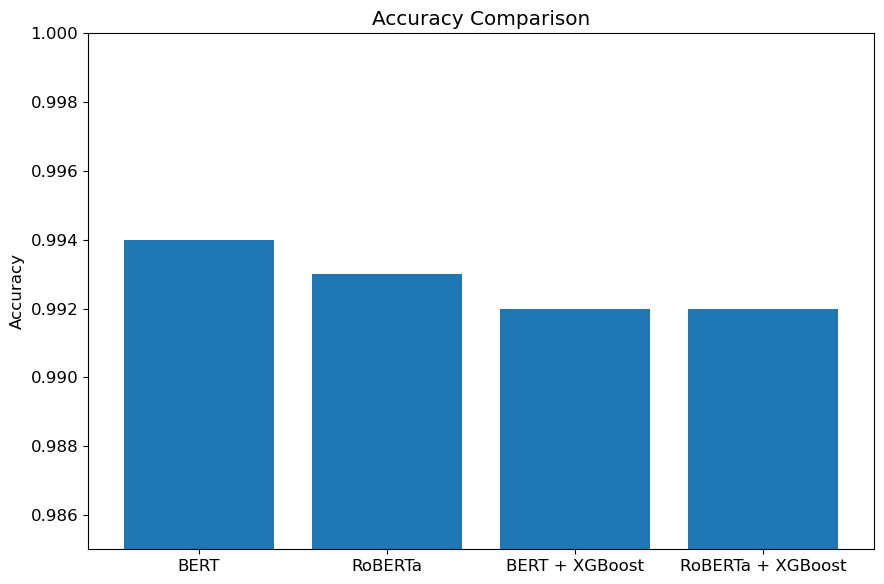

In [13]:
plt.figure(figsize=(9,6))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylim(0.985,1.0)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.tight_layout()

plt.savefig(

    FIGURES / "chapter4_accuracy.png",

    dpi=300

)

plt.show()

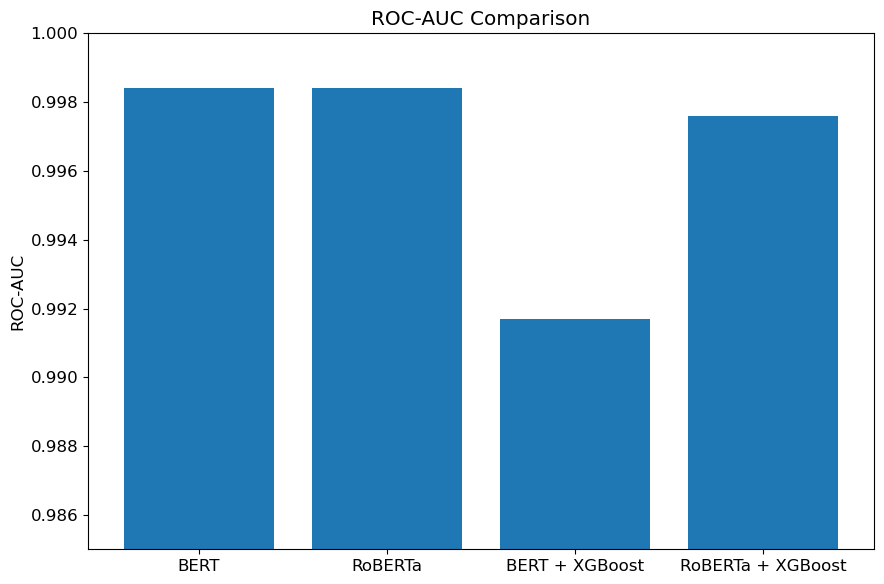

In [14]:
plt.figure(figsize=(9,6))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.ylim(0.985,1.0)

plt.ylabel("ROC-AUC")

plt.title("ROC-AUC Comparison")

plt.tight_layout()

plt.savefig(

    FIGURES / "chapter4_rocauc.png",

    dpi=300

)

plt.show()

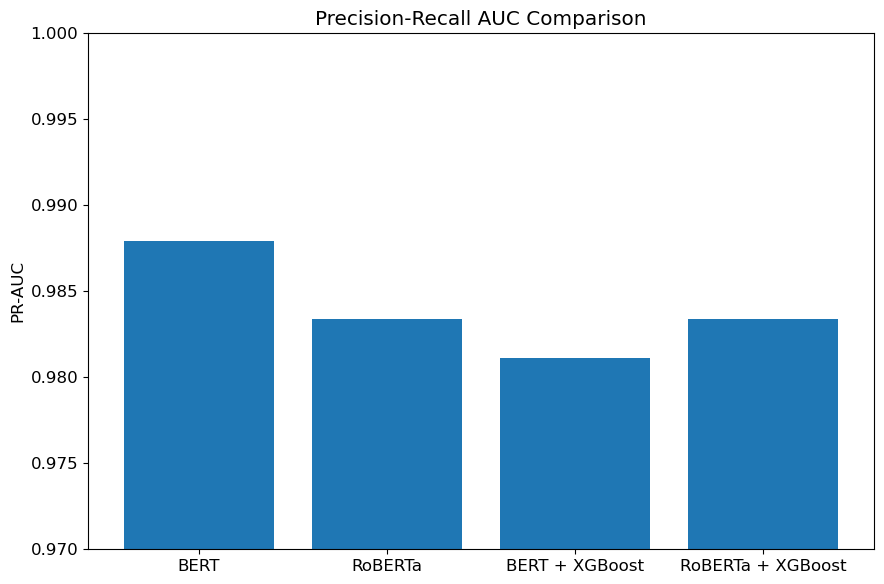

In [15]:
plt.figure(figsize=(9,6))

plt.bar(
    comparison["Model"],
    comparison["PR-AUC"]
)

plt.ylim(0.97,1.0)

plt.ylabel("PR-AUC")

plt.title("Precision-Recall AUC Comparison")

plt.tight_layout()

plt.savefig(

    FIGURES / "chapter4_prauc.png",

    dpi=300

)

plt.show()

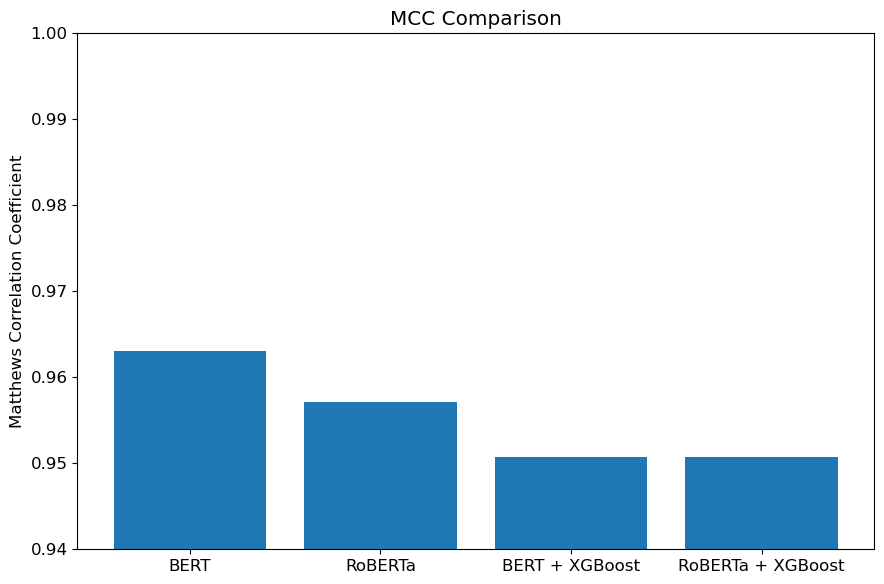

In [16]:
plt.figure(figsize=(9,6))

plt.bar(
    comparison["Model"],
    comparison["MCC"]
)

plt.ylim(0.94,1.0)

plt.ylabel("Matthews Correlation Coefficient")

plt.title("MCC Comparison")

plt.tight_layout()

plt.savefig(

    FIGURES / "chapter4_mcc.png",

    dpi=300

)

plt.show()

In [17]:
ranking = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

display(ranking)

ranking.to_csv(

    REPORTS / "chapter4_model_ranking.csv",

    index=False

)

,Model,Accuracy,Balanced Accuracy,ROC-AUC,PR-AUC,MCC,Cohen Kappa
0,BERT,0.994,0.9767,0.9984,0.9879,0.9631,0.9630
1,RoBERTa,0.993,0.9761,0.9984,0.9834,0.9571,0.9570
2,BERT + XGBoost,0.992,0.9706,0.9917,0.9811,0.9507,0.9507
3,RoBERTa + XGBoost,0.992,0.9706,0.9976,0.9834,0.9507,0.9507


In [18]:
explainability = pd.DataFrame({

    "Aspect":[

        "Model Type",
        "Primary Explanation",
        "Local Explanation",
        "Global Explanation",
        "Word-Level Interpretation",
        "Embedding-Level Interpretation",
        "Computational Cost",
        "Deployment Suitability"

    ],

    "LIME":[

        "Transformer",
        "Word Importance",
        "Excellent",
        "Limited",
        "Yes",
        "No",
        "Lower",
        "Excellent"

    ],

    "SHAP":[

        "Hybrid Transformer + XGBoost",
        "Feature Contribution",
        "Excellent",
        "Excellent",
        "No",
        "Yes",
        "Higher",
        "Excellent"

    ]

})

display(explainability)

explainability.to_csv(

    REPORTS / "chapter4_explainability_comparison.csv",

    index=False

)

,Aspect,LIME,SHAP
0,Model Type,Transformer,Hybrid Transformer + XGBoost
1,Primary Explanation,Word Importance,Feature Contribution
2,Local Explanation,Excellent,Excellent
3,Global Explanation,Limited,Excellent
4,Word-Level Interpretation,Yes,No
5,Embedding-Level Interpretation,No,Yes
6,Computational Cost,Lower,Higher
7,Deployment Suitability,Excellent,Excellent


# Key Findings

The comparative evaluation demonstrates that all four models achieved excellent predictive performance on the phishing email detection task.

Among the evaluated models, the fine-tuned BERT model achieved the highest classification accuracy (99.40%), closely followed by the fine-tuned RoBERTa model (99.30%). The hybrid Transformer–XGBoost architectures also demonstrated strong predictive capability, although they achieved slightly lower overall accuracy.

The results suggest that fine-tuning modern Transformer models alone is sufficient to capture the semantic characteristics of phishing emails in the evaluated dataset. While the hybrid architecture provides additional interpretability through SHAP and separates representation learning from classification, it did not outperform the end-to-end Transformer models in terms of predictive accuracy in this study.

From an explainability perspective, LIME provides intuitive word-level local explanations for Transformer predictions, whereas SHAP offers mathematically grounded local and global feature attribution for the hybrid models. The two techniques are complementary and together enhance the transparency and trustworthiness of phishing email detection systems.